In [80]:
from ESF_gurobipy_VB2000_Ex1 import parallel_calculate_sm_esf_processes, generate_design_vectors_sobol
from ppopt.mplp_program import MPLP_Program
from ppopt.mpmodel import MPModeler
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm
import numpy as np
from collections import defaultdict
from typing import List
from scipy.optimize import linprog
import warnings
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import gurobipy as gp
from gurobipy import GRB
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from scipy.optimize import curve_fit

##############################################################################################################
# FEASIBILITY FUNCTION AND UNCERTAINTY BOUNDS
##############################################################################################################

In [3]:
def mpformulate_theta_bounds(flex_sol, num_theta: int, theta_bounds: list, num_design: int = 0, design_bounds: list = None, psi_idx: int = 0, theta_m: int = 0):
    A0, b0, F0 = np.empty((len(flex_sol), num_theta)), np.empty(
        (len(flex_sol), 1)), np.empty((len(flex_sol), num_design))
    num_cr = len(flex_sol.critical_regions)
    for i, region in enumerate(flex_sol.critical_regions):
        A0[i] = region.A[psi_idx, :num_theta]
        b0[i] = -region.b[psi_idx]
        F0[i] = -region.A[psi_idx, num_theta:num_theta+num_design]
    # print(f'num_cr:{num_cr}')
    # print(f'num_theta:{num_theta}')
    # print(f'num_design:{num_design}')
    # print(f"A0: {A0}")
    # print(f"b0: {b0}")
    # print(f"F0: {F0}")

    c = np.hstack([np.array([-1, 1]).reshape(1, -1),
                  np.zeros((1, 2 * (num_theta - 1 - theta_m)))]).reshape(-1, 1)
    # print(f'c:{c}')
    # print(f'c.shape: {c.shape}')

    row1_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (A0[:, [i]], np.zeros((num_cr, 1)))])
    row2_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (np.zeros((num_cr, 1)), A0[:, [i]])])
    bound_row = np.hstack([np.array([-1, 1]).reshape(1, -1),
                          np.zeros((1, 2 * (num_theta - 1 - theta_m)))])
    A = np.vstack([row1_block, row2_block, bound_row, -
                  np.eye(2*(num_theta-theta_m)), np.eye(2*(num_theta-theta_m))])
    # print(f'A: {A}')
    # print(f'A.shape: {A.shape}')

    x_lb = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][0]] * 2])
    x_ub = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][1]] * 2])
    b = np.vstack([b0, b0, np.zeros((1, 1)), -
                  x_lb.reshape(-1, 1), x_ub.reshape(-1, 1)])
    # print(f'b: {b}')
    # print(f'b.shape: {b.shape}')

    if F0.size == 0 and theta_m == 0:
        # print('here')
        return A, b, c, np.array([]), np.array([]), np.array([]), np.array([])

    F = np.vstack([F0, F0, np.zeros((1, num_design)), np.zeros(
        (4*(num_theta-theta_m), num_design))]) if num_design > 0 else np.vstack([F0, F0])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')
    if theta_m > 0:
        F_lltheta = np.hstack([A0[:, [i]] for i in range(theta_m)])
        # print(f'F_lltheta: {F_lltheta}')
        # print(f'F_lltheta.shape: {F_lltheta.shape}')
        F = np.hstack([np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))]), F]
                      ) if F.size > 0 else np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')

    H = np.zeros((2*(num_theta-theta_m), theta_m+num_design))
    # print(f'H:{H}')
    # print(f'H.shape: {H.shape}')

    A_t = np.vstack([-np.eye(theta_m+num_design), np.eye(theta_m+num_design)])
    # print(f'A_t:{A_t}')
    # print(f'A_t.shape: {A_t.shape}')

    theta_lb = np.array([-theta_bounds[i][0] for i in range(theta_m)] + ([-j[0] for j in design_bounds] if isinstance(design_bounds, list)
                                                                         else [])).reshape(-1, 1)
    theta_ub = np.array([theta_bounds[i][1] for i in range(theta_m)] + ([j[1] for j in design_bounds] if isinstance(design_bounds, list)
                                                                        else [])).reshape(-1, 1)

    b_t = np.vstack([theta_lb, theta_ub])
    # print(f'b_t:{b_t}')
    # print(f'b_t.shape: {b_t.shape}')

    return A, b, c, H, A_t, b_t, F

def get_theta_bounds(flex_sol, numt, tbounds, numd: int = 0, dbounds: list = None, mp_algo: mpqp_algorithm = mpqp_algorithm.combinatorial):
    theta_bound_dict = defaultdict(dict)
    prob_dict = defaultdict(dict)

    for i in range(numt):
        A, b, c, H, A_t, b_t, F = mpformulate_theta_bounds(
            flex_sol=flex_sol, num_theta=numt, num_design=numd, theta_bounds=tbounds, design_bounds=dbounds, theta_m=i)
        # print(f'A.shape:{A.shape}')
        # print(f'b.shape: {b.shape}')
        # print(f'F.shape: {F.shape}')
        if F.size != 0:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("error", category=UserWarning, message="The chebychev ball has either a radius of zero, or the problem is not feasible!")
                    prob = MPLP_Program(A=A, b=b, c=c, H=H, A_t=A_t, b_t=b_t, F=F)

                prob.process_constraints()
                solution = solve_mpqp(problem=prob, algorithm=mp_algo)

                prob_dict[f"t{i}"] = prob
                theta_bound_dict[f"t{i}"] = solution

            except UserWarning as w:
                # MPLP infeasible / degenerate
                print(f"[theta {i}] MPLP infeasible / zero Chebyshev ball: {w}")
                prob_dict[f"t{i}"] = None
                theta_bound_dict[f"t{i}"] = None

        else:
            # LP fallback branch via scipy.optimize.linprog
            linres = linprog(c=c, A_ub=A, b_ub=b)

            if not linres.success:
                print(f"[theta {i}] linprog failed: status={linres.status}, "f"message={linres.message}")
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = None
            else:
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = [linres.x[1], linres.x[0]]

        print(f"Finished solving for theta{i+1}")

    probs = [p for _, p in prob_dict.items()]
    sols = [sol for _, sol in theta_bound_dict.items()]
    return probs, sols


def get_bounds_regions(sols: List, min_idx: int = 1, max_idx: int = 0):
    t_bounds_list = []
    t_regions_list = []

    for theta_sol in sols:
        if theta_sol is None:
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        if not getattr(theta_sol, "critical_regions", None):
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        min_max_list = []
        region_list = []

        for cr in theta_sol.critical_regions:
            # Store bounds
            Ab = np.concatenate([cr.A, cr.b], axis=1)[:2]
            min_max_list.append([Ab[min_idx].tolist(), Ab[max_idx].tolist()])

            # Store region constraints
            Ef = np.concatenate([cr.E, -cr.f], axis=1)
            region_array = np.array([row.tolist() for row in Ef], dtype=float)
            region_list.append(region_array)

        # Append per-theta data
        t_bounds_list.append(np.array(min_max_list))
        # <-- each region is a 2D array
        t_regions_list.append(np.array(region_list, dtype=object))

    return t_bounds_list, t_regions_list

##############################################################################################################
# PREPARE STATE DATA
##############################################################################################################

In [4]:
def _prepare_state_data(state, tbounds, dbounds, *, solve_algo, theta_algo, log=False):
    """
    Build and solve the flexibility problem for one state, then return only valid theta-related data.

    Returns
    -------
    dict with keys:
        state
        flex_sol
        sol_list
        t_bounds_list
        t_regions_list
        filtered_solutions
        filtered_theta_bounds
        filtered_theta_regions
    or None if no valid theta regions exist.
    """
    state_model = create_flexibility_model(y_list=state, tbounds=tbounds, dbounds=dbounds)
    state_prob = state_model.formulate_problem()
    state_prob.process_constraints()

    flex_sol = solve_mpqp(problem=state_prob, algorithm=solve_algo)
    
    numt = len(tbounds)
    numd = len(dbounds)

    if log:
        print(
            f"Number of critical regions in for flexibility function for state {state}: {len(flex_sol.critical_regions)}")

    _, sol_list = get_theta_bounds(flex_sol=flex_sol, numt=numt, numd=numd, tbounds=tbounds, dbounds=dbounds,
                                   mp_algo=theta_algo)

    t_bounds_list, t_regions_list = get_bounds_regions(sols=sol_list)

    filtered_solutions = []
    filtered_theta_bounds = []
    filtered_theta_regions = []

    for k, (sol, tb, tr) in enumerate(zip(sol_list, t_bounds_list, t_regions_list)):
        if sol is None or tb is None or tr is None:
            # mark as empty stage but preserve position
            filtered_solutions.append(None)
            filtered_theta_bounds.append(None)
            filtered_theta_regions.append(None)
        else:
            filtered_solutions.append(sol)
            filtered_theta_bounds.append(tb)
            filtered_theta_regions.append(tr)

    return {
        "state": state,
        "flex_sol": flex_sol,
        "sol_list": sol_list,
        "theta_bounds_list": t_bounds_list,
        "theta_regions_list": t_regions_list,
        "filtered_solutions": filtered_solutions,
        "filtered_theta_bounds": filtered_theta_bounds,
        "filtered_theta_regions": filtered_theta_regions,
    }

##############################################################################################################
# CASE STUDY
##############################################################################################################

In [5]:
# Bansal (2000) Process Example 1
y_dict = {
    (0, 0, 0): 0.001,
    (0, 0, 1): 0.003,
    (0, 1, 0): 0.006,
    (1, 0, 0): 0.010,
    (0, 1, 1): 0.040,
    (1, 0, 1): 0.066,
    (1, 1, 0): 0.114,
    (1, 1, 1): 0.760
}

t_bounds = [(8, 16), (3, 11)]
d_bounds = [(0, 10), (0, 10), (0, 10)]
nt = len(t_bounds)
nd = len(d_bounds)

feasibility_algo = mpqp_algorithm.combinatorial_parallel
theta_bounds_algo = mpqp_algorithm.combinatorial_parallel

feas_algo_name = 'gp' if feasibility_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
tb_algo_name = 'gp' if theta_bounds_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')

case_study = 'VB2000_Ex1'
quad_method = 'smolyak'
smolyak_level = 16

def create_flexibility_model(tbounds: list, dbounds: list, y_list: tuple = None):
    j1 = 0.92
    j2 = 0.85
    j3 = 0.75

    m = MPModeler()

    u = m.add_var(name='u')
    F1 = m.add_var(name="F1")
    F2 = m.add_var(name="F2")
    F3 = m.add_var(name="F3")
    F4 = m.add_var(name="F4")
    F5 = m.add_var(name="F5")
    F6 = m.add_var(name="F6")
    F7 = m.add_var(name="F7")

    S = m.add_param(name='S')
    D = m.add_param(name='D')

    d1 = m.add_param(name='d1')
    d2 = m.add_param(name='d2')
    d3 = m.add_param(name='d3')

    m.add_constr(F4 - j1 * F2 == 0)
    m.add_constr(F1 - F2 - F3 == 0)
    m.add_constr(F5 - j2 * F4 == 0)
    m.add_constr(F6 - j3 * F3 == 0)
    m.add_constr(F7 - F5 - F6 == 0)
    m.add_constr(F1 - S <= u)
    m.add_constr(D - F7 <= u)
    m.add_constr(F2 - d1 * y_list[0] <= u)
    m.add_constr(F4 - d2 * y_list[1] <= u)
    m.add_constr(F3 - d3 * y_list[2] <= u)

    # for v in [F1, F2, F3, F4, F5, F6, F7]:
    #     m.add_constr(v >= 0)

    m.add_constr(tbounds[0][0] + 1e-6 <= S)
    m.add_constr(S <= tbounds[0][1])
    m.add_constr(tbounds[1][0] + 1e-6 <= D)
    m.add_constr(D <= tbounds[1][1])

    m.add_constr(dbounds[0][0] <= d1)
    m.add_constr(d1 <= dbounds[0][1])
    m.add_constr(dbounds[1][0] <= d2)
    m.add_constr(d2 <= dbounds[1][1])
    m.add_constr(dbounds[2][0] <= d3)
    m.add_constr(d3 <= dbounds[2][1])

    m.set_objective(u)

    return m

def joint_pdf(theta: list):
    Sval, Dval = theta
    eps = 1e-12
    x = max(Sval - 8.0, eps)
    return (1 / (1.2 * np.pi * x)) * np.exp(
        -1.39 * (np.log(x)) ** 2 - 0.5 * (Dval - 7.0) ** 2)

cost_coeff_list = [2,3,5]
def cost_function(d):
    coeffs = np.array(cost_coeff_list)
    return float(np.dot(coeffs, d))

In [6]:
# prepared_data_by_state = {
#     state: _prepare_state_data(
#         state,
#         tbounds=t_bounds,
#         dbounds=d_bounds,
#         solve_algo=feasibility_algo,
#         theta_algo=theta_bounds_algo,
#     )
#     for state in y_dict
# }
# 
# load_prepared_data_by_state = prepared_data_by_state

In [7]:
ns=1024*8

In [8]:
ns

8192

In [9]:
dvector_list_sobol = generate_design_vectors_sobol(d_bounds, n_samples=ns)

In [10]:
# results = parallel_calculate_sm_esf_processes(
#     design_vectors=dvector_list_sobol,
#     y_d=y_dict,
#     load_prepared_data_by_s=load_prepared_data_by_state,
#     s_level=smolyak_level,
#     show_progress=True,
#     # cost_func=cost_function,
#     # joint_func=joint_pdf,
# )

In [11]:
# with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [12]:
with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'rb') as f:
    load_results = pickle.load(f)

##############################################################################################################
# OPTIMAL SIMULATION RESULTS
##############################################################################################################

In [13]:
esf_target_list = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55]

In [14]:
def select_best_design(results, esf_target):
    """
    Select the best design such that:
    1. esf_sm >= esf_target
    2. minimum overshoot above esf_target
    3. tie-breaker: minimum cost
    """
    feasible = [r for r in results if r["esf_sm"] >= esf_target]

    if not feasible:
        return None

    return min(
        feasible,
        key=lambda r: (r["esf_sm"] - esf_target, r["cost"])
    )


In [15]:
sim_esf_list, sim_cost_list = list(), list()
for esf in esf_target_list:
    best_result = select_best_design(load_results, esf)
    if best_result is not None:
        sim_esf_list.append(best_result['esf_sm'])
        sim_cost_list.append(best_result['cost'])

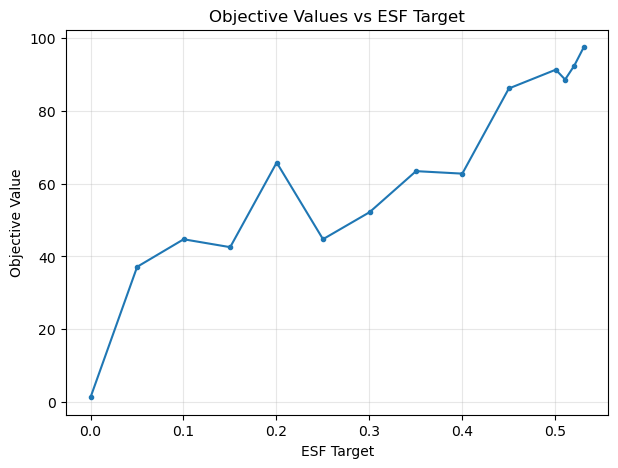

In [16]:
plt.figure(figsize=(7,5))
plt.plot(sim_esf_list, sim_cost_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
# plt.xscale("log")
# plt.yscale("log")   # optional but often useful
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()

##############################################################################################################
# REGRESSION
##############################################################################################################

In [58]:
def build_regression_dataset(results):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"] for r in results])
    return X, y

def fit_polynomial_esf_model_zero_intercept(results, degree=2):
    """
    Polynomial regression with intercept forced to zero:
    esf_sm ≈ sum_j coef_j * feature_j, no constant term.
    """
    X, y = build_regression_dataset(results)

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression(fit_intercept=False)),
    ])

    model.fit(X, y)
    return model

def fit_exponential_esf_model(results, degree=1, tol=1e-6):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"]+tol for r in results])

    if np.any(y <= 0):
        raise ValueError("Need y > 0 for log-transform exponential model.")

    base_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    model = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log,
        inverse_func=np.exp,
    )

    model.fit(X, y)
    return model

In [60]:
def plot_actual_vs_predicted_poly(model, X, y, title_prefix="Polynomial regression"):
    # Predictions
    y_pred = model.predict(X)

    # Metrics (optional but useful)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.5, edgecolor="k")
    plt.xlabel("Actual esf_sm")
    plt.ylabel("Predicted esf_sm")

    title = f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}"
    plt.title(title)

    # 45-degree line
    min_v = min(y.min(), y_pred.min())
    max_v = max(y.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [61]:
def plot_regression_diagnostics(
    model,
    X,
    y,
    title_prefix="Regression model",
    figsize=(12, 5),
    point_alpha=0.35,
    point_size=30,
):
    """
    Plot:
      1) Actual vs predicted
      2) Residuals vs predicted

    Works for any fitted model with model.predict(X).
    """
    y = np.asarray(y)
    y_pred = np.asarray(model.predict(X))
    residuals = y - y_pred

    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Left: Actual vs predicted ----
    ax = axes[0]
    ax.scatter(
        y,
        y_pred,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )

    min_v = min(np.min(y), np.min(y_pred))
    max_v = max(np.max(y), np.max(y_pred))
    ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    ax.set_xlabel("Actual esf_sm")
    ax.set_ylabel("Predicted esf_sm")
    ax.set_title(f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}")
    ax.grid(alpha=0.2)

    # Optional: keep same scales visually
    ax.set_xlim(min_v, max_v)
    ax.set_ylim(min_v, max_v)

    # ---- Right: Residuals vs predicted ----
    ax = axes[1]
    ax.scatter(
        y_pred,
        residuals,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )
    ax.axhline(0.0, color="r", linestyle="--", linewidth=2)

    ax.set_xlabel("Predicted esf_sm")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs predicted")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [62]:
reg_degree = nd

In [63]:
poly_model = fit_polynomial_esf_model_zero_intercept(load_results, degree=reg_degree)

poly = poly_model.named_steps["poly"]
lin = poly_model.named_steps["linreg"]

print("Intercept:", lin.intercept_)     # should be 0.0 (or very close numerically)
print("Num features:", len(poly.get_feature_names_out()))

Intercept: 0.0
Num features: 19


In [64]:
feature_names = poly.get_feature_names_out()
coefs = lin.coef_  # no intercept

In [65]:
feature_names

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2',
       'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3'], dtype=object)

In [66]:
X, y = build_regression_dataset(load_results)

In [67]:
# exp_model_deg2 = fit_exponential_esf_model(load_results, degree=3)

In [68]:
# plot_regression_diagnostics(
#     exp_model_deg2,
#     X,
#     y,
#     title_prefix="Log-quadratic exp model: esf_sm"
# )

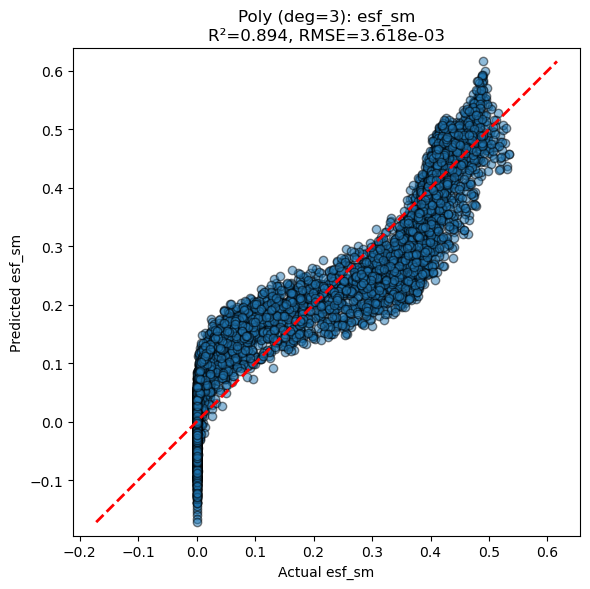

In [69]:
plot_actual_vs_predicted_poly(poly_model, X, y, title_prefix=f"Poly (deg={reg_degree}): esf_sm")

##############################################################################################################
# EXPERIMENT
##############################################################################################################

In [87]:
class SinhRegressorSeparate:
    def __init__(self, p0=(1,1,0, 1,1,0, 1,1,0, 0), maxfev=50000):
        self.p0 = p0
        self.maxfev = maxfev
        self.params_ = None
        self.pcov_ = None

    @staticmethod
    def _model(X_tuple, a1, b1, c1, a2, b2, c2, a3, b3, c3, d):
        x1, x2, x3 = X_tuple
        term1 = a1 * np.sinh(b1 * x1 + c1)
        term2 = a2 * np.sinh(b2 * x2 + c2)
        term3 = a3 * np.sinh(b3 * x3 + c3)
        return term1 + term2 + term3 + d

    def fit(self, X, y):
        X = np.asarray(X); y = np.asarray(y)
        x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
        popt, pcov = curve_fit(
            self._model,
            (x1, x2, x3),
            y,
            p0=self.p0,
            maxfev=self.maxfev,
        )
        self.params_ = popt
        self.pcov_ = pcov
        return self

    def predict(self, X):
        if self.params_ is None:
            raise RuntimeError("Model not fitted.")
        X = np.asarray(X)
        x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
        return self._model((x1, x2, x3), *self.params_)

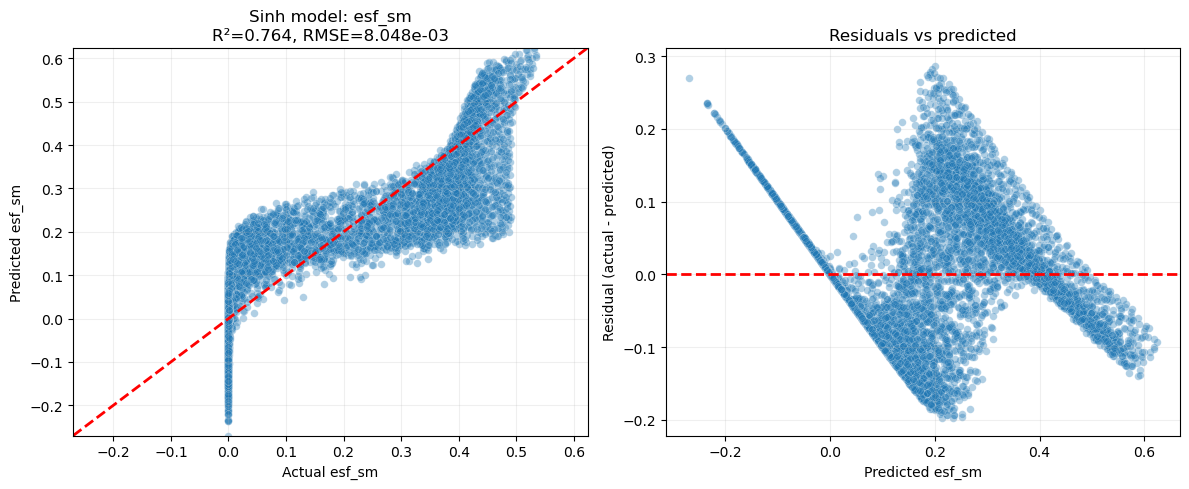

In [88]:
sinh_model = SinhRegressorSeparate()
sinh_model.fit(X, y)

plot_regression_diagnostics(
    sinh_model,
    X,
    y,
    title_prefix="Sinh model: esf_sm"
)

In [90]:
print("params_:", sinh_model.params_)

a1, a2, a3, b1, b2, b3, c1, c2, c3, d = sinh_model.params_
# print(f"a={a1}, b1={b1}, b2={b2}, b3={b3}, c={c}, d={d}")

params_: [ 3.81381600e-03  1.22825834e-01 -5.20930096e+00  1.21501092e-03
  1.85824073e-01 -6.12434066e+00  9.31041839e-03  6.89934188e-02
  4.57668144e+00 -1.14637569e-01]


##############################################################################################################
# GUROBI MODEL
##############################################################################################################

In [59]:
def feature_to_expr(name, d_vars):
    """
    Convert a PolynomialFeatures feature name to a Gurobi expression
    in variables d_vars (tupledict or list of decision variables).
    Supports feature names like: 'x0', 'x1^2', 'x0 x1', 'x0^2 x2', etc.
    """
    # Single variable, maybe with power
    if "^" in name and " " not in name:
        base, pow_str = name.split("^")
        idx = int(base[1:])  # 'x0' -> 0
        power = int(pow_str)
        expr = d_vars[idx]
        for _ in range(power - 1):
            expr = expr * d_vars[idx]  # quadratic or higher
        return expr

    # Product of different variables, maybe repeated: 'x0 x1', 'x0^2 x2', etc.
    parts = name.split(" ")
    expr = 1.0
    for p in parts:
        if "^" in p:
            base, pow_str = p.split("^")
            idx = int(base[1:])
            power = int(pow_str)
            term = d_vars[idx]
            for _ in range(power - 1):
                term = term * d_vars[idx]
        else:
            idx = int(p[1:])
            term = d_vars[idx]
        expr = expr * term
    return expr

In [70]:
def build_base_gurobi_model(dbounds, features, coeffs, intercept=0.0, cost_builder=None, esf_target_init=0.0):
    m = gp.Model("ESF_design")

    d = m.addVars(
        len(d_bounds),
        lb=[b[0] for b in dbounds],
        ub=[b[1] for b in dbounds],
        name="d"
    )

    ESF = m.addVar(lb=0, name="ESF")
    Cost = m.addVar(lb=0, name="Cost")
    
    if cost_builder is None:
        cost_expr = gp.quicksum(d[j] for j in d.keys())
    else:
        cost_expr = gp.quicksum(cost_builder[j]*d[j] for j in d.keys())
        
    m.addConstr(Cost == cost_expr, name='cost_expr')
    
    m.addConstr(ESF >= esf_target_init, name="esf_target_con")
    
    m.setObjective(Cost, GRB.MINIMIZE)
    
    m._esf_expr = intercept
    # m.update()
    for name, coef in zip(features, coeffs):
        if abs(coef) < 1e-12:
            continue
        m._esf_expr += coef * feature_to_expr(name, d)  # d are your Gurobi vars
        # print(esf_expr)
    
    m.addConstr(ESF == m._esf_expr, name="esf_expr")
    
    m.update()
    
    return m

In [71]:
grb_model = build_base_gurobi_model(dbounds=d_bounds, cost_builder=cost_coeff_list, features=feature_names, coeffs=coefs, intercept=lin.intercept_)

In [72]:
esf_expr = grb_model._esf_expr
esf_expr

<gurobi.NLExpr: -0.002979743411969814 * d[0] + 0.0015979800686862404 * d[1] + -0.08957531101047668 * d[2] + -0.0024788170550096886 * d[0]**2 + 0.0022601900477284423 * d[0] * d[1] + 0.016261523318240503 * d[0] * d[2] + -0.0024442275653088676 * d[1]**2 + 0.013753406517840997 * d[1] * d[2] + 0.014573306489069642 * d[2]**2 + 8.079395344192068e-05 * d[0]**2 * d[0] + 0.0004084322740936121 * d[0]**2 * d[1] + -0.0005317672977407364 * d[0]**2 * d[2] + 0.00016496776933628307 * d[1]**2 * d[0] + -0.0005251926347059551 * d[0] * d[1] * d[2] + -0.0010067498187204505 * d[2]**2 * d[0] + 6.167776089994746e-05 * d[1]**2 * d[1] + -0.0003688363325486506 * d[1]**2 * d[2] + -0.0009074586162681577 * d[2]**2 * d[1] + -0.0002453983809089442 * d[2]**2 * d[2]>

In [73]:
trade_off_dict = {}
for eps in esf_target_list:
    
    esf_target_con = grb_model.getConstrByName('esf_target_con')
    esf_target_con.RHS = eps
    
    grb_model.optimize()
    
    d_list = list()
    for j in range(len(d_bounds)):
        temp_var = grb_model.getVarByName(f'd[{j}]')
        d_list.append(temp_var.X)
    
    ESF_var = grb_model.getVarByName('ESF')
    
    trade_off_dict[eps] = {
        'design': np.array(d_list),
        'cost': grb_model.ObjVal,
        'ESF': ESF_var.X
    }

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2 rows, 5 columns and 5 nonzeros
Model fingerprint: 0x6882e5c8
Model has 1 general nonlinear constraint (26 nonlinear terms)
Variable types: 5 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+01, 1e+01]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 24 available processors)

Solution count 1: 0 

Optimal solution found (tolerance 1.00e-04)
Best objective 0.000000000000e+00, best bound 0.000000000000e+00, gap 0.0000%
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))



In [74]:
trade_off_dict

{0: {'design': array([0., 0., 0.]), 'cost': 0.0, 'ESF': 0.0},
 0.05: {'design': array([6.9476546 , 5.10207611, 0.        ]),
  'cost': 29.20153753675224,
  'ESF': 0.05},
 0.1: {'design': array([8.33237298, 5.59276389, 0.        ]),
  'cost': 33.44303762139478,
  'ESF': 0.1},
 0.15: {'design': array([9.38249864, 5.92375325, 0.        ]),
  'cost': 36.536257023012176,
  'ESF': 0.15},
 0.2: {'design': array([9.99999999, 6.35171803, 0.        ]),
  'cost': 39.055154050283065,
  'ESF': 0.2},
 0.25: {'design': array([10.        ,  7.14844032,  0.        ]),
  'cost': 41.445320967442996,
  'ESF': 0.25},
 0.3: {'design': array([10.        ,  7.93470085,  0.        ]),
  'cost': 43.80410254198352,
  'ESF': 0.3},
 0.35: {'design': array([10.       ,  8.7081962,  0.       ]),
  'cost': 46.12458859078636,
  'ESF': 0.35},
 0.4: {'design': array([10.        ,  9.46701629,  0.        ]),
  'cost': 48.401048874459484,
  'ESF': 0.4},
 0.45: {'design': array([10.        , 10.        ,  0.21236663]),
  '

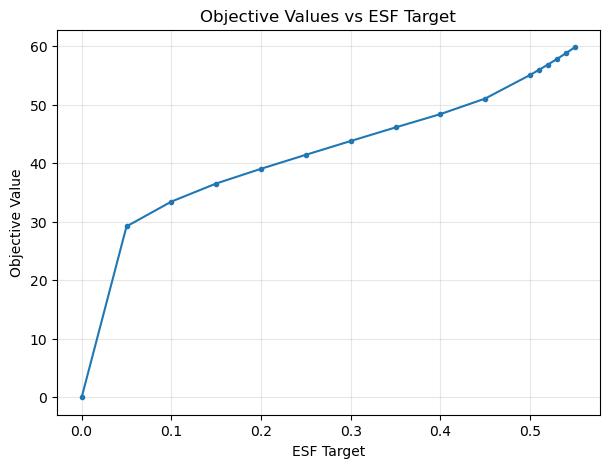

In [75]:
trade_off_esf_list = list(trade_off_dict.keys())
trade_off_cost_list = [v['cost'] for k,v in trade_off_dict.items()]

plt.figure(figsize=(7,5))
plt.plot(trade_off_esf_list, trade_off_cost_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()